# Bài 1: 

In [18]:
import data_preprocessing as dp
import logistic_regression as lr
import matplotlib.pyplot as plt

Kích thước X_train: (12665, 784)
Kích thước Y_train: (12665, 1)

Khởi tạo mô hình Logistic Regression...
Bắt đầu huấn luyện...


Training:   0%|          | 0/100 [00:00<?, ?it/s]d:\HK3-UIT-2025_2026\Học máy thống kê - DS102.Q22\Thực hành\Buổi 2\logistic_regression.py:15: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-z))
Training: 100%|██████████| 100/100 [00:00<00:00, 176.04it/s]


Huấn luyện thành công!

Kết quả đánh giá trên tập huấn luyện:
- Precision: 0.9988
- Recall: 0.9982
- F1 Score: 0.9985


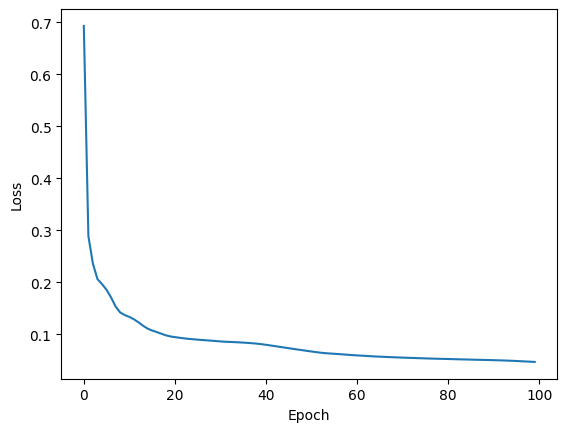

In [19]:
X_train = dp.train_images
X_train = X_train.reshape(X_train.shape[0], -1) # Kéo phẳng từ (N, 28, 28) thành (N, 784)
Y_train = dp.train_labels.reshape(-1, 1) # Reshape nhãn về kích thước (N, 1)
    
# Chuẩn hóa dữ liệu ảnh về đoạn [0, 1]
X_train = X_train / 255.0
    
print(f"Kích thước X_train: {X_train.shape}")
print(f"Kích thước Y_train: {Y_train.shape}")

# Khởi tạo mô hình
print("\nKhởi tạo mô hình Logistic Regression...")
model = lr.LogisticRegression(epoch=100, lr=0.01)
    
# Huấn luyện mô hình
print("Bắt đầu huấn luyện...")
model.fit(X_train, Y_train)
print("Huấn luyện thành công!")
    
# Đánh giá trên tập huấn luyện
Y_pred_probs = model.predict(X_train)
Y_pred = (Y_pred_probs >= 0.5).astype(int)
    
result = model.evaluate(Y_train, Y_pred)
print("\nKết quả đánh giá trên tập huấn luyện:")
print(f"- Precision: {result['precision']:.4f}")
print(f"- Recall: {result['recall']:.4f}")
print(f"- F1 Score: {result['f1_score']:.4f}")
    
# Vẽ đồ thị loss
plt.plot(model.losses)
plt.xlabel("Epoch")    
plt.ylabel("Loss")
plt.show()

# Bài 2:

In [20]:
import softmax_regression as sr

Kích thước X_train: (12665, 784)
Kích thước Y_train: (12665,)
Kích thước Y_train_onehot: (12665, 2)

Khởi tạo mô hình Softmax Regression...
Bắt đầu huấn luyện...


Training:   0%|          | 0/100 [00:00<?, ?it/s]

Training: 100%|██████████| 100/100 [00:01<00:00, 88.08it/s]


Huấn luyện thành công!

Kết quả đánh giá trên tập huấn luyện:
- Precision: 0.9977
- Recall: 0.9976
- F1 Score: 0.9976


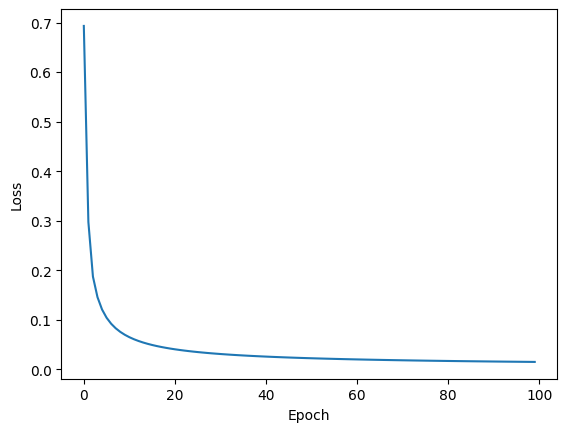

In [21]:
import numpy as np
import matplotlib.pyplot as plt

def one_hot_encode(y, num_classes=None):
    y = y.astype(int).reshape(-1)
    if num_classes is None:
        num_classes = np.max(y) + 1
    return np.eye(num_classes)[y]

X_train = dp.train_images
X_train = X_train.reshape(X_train.shape[0], -1)
Y_train = dp.train_labels.astype(int)
Y_train_onehot = one_hot_encode(Y_train)

# Chuẩn hóa dữ liệu ảnh về [0, 1]
X_train = X_train / 255.0

print(f"Kích thước X_train: {X_train.shape}")
print(f"Kích thước Y_train: {Y_train.shape}")
print(f"Kích thước Y_train_onehot: {Y_train_onehot.shape}")

# Khởi tạo mô hình Softmax Regression
print("\nKhởi tạo mô hình Softmax Regression...")
model = sr.SoftmaxRegression(epoch=100, lr=0.1)

# Huấn luyện mô hình với nhãn one-hot
print("Bắt đầu huấn luyện...")
model.fit(X_train, Y_train_onehot)
print("Huấn luyện thành công!")

# Dự đoán và đánh giá trên tập huấn luyện
Y_pred_probs = model.predict(X_train)
Y_pred = np.argmax(Y_pred_probs, axis=1)

result = model.evaluate(Y_train, Y_pred)
print("\nKết quả đánh giá trên tập huấn luyện:")
print(f"- Precision: {result['precision']:.4f}")
print(f"- Recall: {result['recall']:.4f}")
print(f"- F1 Score: {result['f1_score']:.4f}")

# Vẽ đồ thị loss
plt.plot(model.losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

# Bài 3:

In [22]:
from sklearn.linear_model import LogisticRegression as SklearnLogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

X_train = dp.train_images.reshape(dp.train_images.shape[0], -1) / 255.0
Y_train = dp.train_labels.astype(int).reshape(-1)

print(f"Kich thuoc X_train: {X_train.shape}")
print(f"Kich thuoc Y_train: {Y_train.shape}")

clf_logistic = SklearnLogisticRegression(
    max_iter=120,
    solver="liblinear",
    random_state=42
)
clf_logistic.fit(X_train, Y_train)
y_pred_logistic = clf_logistic.predict(X_train)

result_logistic = {
    "Accuracy": accuracy_score(Y_train, y_pred_logistic),
    "Precision": precision_score(Y_train, y_pred_logistic, average="binary", zero_division=0),
    "Recall": recall_score(Y_train, y_pred_logistic, average="binary", zero_division=0),
    "F1": f1_score(Y_train, y_pred_logistic, average="binary", zero_division=0),
}

clf_softmax = SklearnLogisticRegression(
    max_iter=120,
    solver="saga",
    tol=1e-2,
    random_state=42
)
clf_softmax.fit(X_train, Y_train)
y_pred_softmax = clf_softmax.predict(X_train)

result_softmax = {
    "Accuracy": accuracy_score(Y_train, y_pred_softmax),
    "Precision": precision_score(Y_train, y_pred_softmax, average="macro", zero_division=0),
    "Recall": recall_score(Y_train, y_pred_softmax, average="macro", zero_division=0),
    "F1": f1_score(Y_train, y_pred_softmax, average="macro", zero_division=0),
}

print("\nKet qua sklearn Logistic Regression: ")
for k, v in result_logistic.items():
    print(f"{k}: {v:.4f}")

print("\nKet qua sklearn Softmax Regression (multinomial):")
for k, v in result_softmax.items():
    print(f"{k}: {v:.4f}")

Kich thuoc X_train: (12665, 784)
Kich thuoc Y_train: (12665,)

Ket qua sklearn Logistic Regression: 
Accuracy: 0.9999
Precision: 1.0000
Recall: 0.9999
F1: 0.9999

Ket qua sklearn Softmax Regression (multinomial):
Accuracy: 0.9994
Precision: 0.9995
Recall: 0.9994
F1: 0.9994
